In [77]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os # File and directory operations
import glob # Search files using wildcard patterns
import h5py # Read HDF5 battery dataset
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


# Week 6 Multi-Feature Battery Lifetime Model

This notebook builds on the Week 5 one-feature baseline model. In Week 6, I prepare additional battery features from the dataset, including early discharge capacity, capacity fade slope, average charge time, and internal resistance. These features will later be used to train a multi-feature regression model and compare it with the Week 5 baseline.

## Goal

The goal for Day 1 is to prepare a clean multi-feature DataFrame. I will keep the Week 5 feature, `log_var_delta_Q`, and add several more features from the battery summary data before training the model later this week.

In [4]:
mat_files_all = glob.glob("/kaggle/input/**/*.mat", recursive=True)

for file in mat_files_all:
    print(file)

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


In [5]:
mat_files = [
    file for file in mat_files_all
    if "varcharge" not in os.path.basename(file)
]

for file in mat_files:
    print(os.path.basename(file))

2017-05-12_batchdata_updated_struct_errorcorrect.mat
2018-02-20_batchdata_updated_struct_errorcorrect.mat
2018-04-12_batchdata_updated_struct_errorcorrect.mat


In [6]:
def read_scalar_from_ref(f, ref):
    # Read a scalar value stored as an HDF5 reference.
    value = np.array(f[ref]).squeeze()
    return float(value)

In [7]:
def compute_deltaQ_feature(file_path, cell_index):
    # Cycle 10 and Cycle 100 are used to compare early-cycle discharge curves.
    # Python uses zero-based indexing, so Cycle 10 = index 9 and Cycle 100 = index 99.
    cycle_10_index = 9
    cycle_100_index = 99
    
    with h5py.File(file_path, "r") as f:
        cycle_life_ref = f["batch"]["cycle_life"][cell_index, 0]
        cycle_life = read_scalar_from_ref(f, cycle_life_ref)
        
        cycles_ref = f["batch"]["cycles"][cell_index, 0]
        cycles = f[cycles_ref]
        
        if "Qdlin" not in cycles.keys():
            return None
        
        num_cycles = cycles["Qdlin"].shape[0]
        if num_cycles <= cycle_100_index:
            return None
        
        Qdlin_10_ref = cycles["Qdlin"][cycle_10_index, 0]
        Qdlin_100_ref = cycles["Qdlin"][cycle_100_index, 0]
        
        Qdlin_10 = np.array(f[Qdlin_10_ref]).squeeze()
        Qdlin_100 = np.array(f[Qdlin_100_ref]).squeeze()
        
        if Qdlin_10.shape != Qdlin_100.shape:
            return None
        
        delta_Q = Qdlin_100 - Qdlin_10
        
        if np.isnan(delta_Q).sum() > 0:
            return None
        
        var_delta_Q = np.var(delta_Q)
        
        if var_delta_Q <= 0:
            return None
        
        log_var_delta_Q = np.log10(var_delta_Q)
        
        return {
            "batch_file": os.path.basename(file_path),
            "cell_index": cell_index,
            "cycle_life": cycle_life,
            "var_delta_Q": var_delta_Q,
            "log_var_delta_Q": log_var_delta_Q
        }

In [9]:
with h5py.File(mat_files[0], "r") as f:
    summary_ref = f["batch"]["summary"][0, 0]
    summary = f[summary_ref]
    
    print(list(summary.keys()))

['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [10]:
def get_summary_df(f, cell_index):
    # Open the summary data for one battery cell.
    summary_ref = f["batch"]["summary"][cell_index, 0]
    summary = f[summary_ref]
    
    summary_data = {}
    
    # Convert each summary field into a NumPy array.
    for key in summary.keys():
        summary_data[key] = np.array(summary[key]).squeeze()
    
    # Convert the summary dictionary into a pandas DataFrame.
    summary_df = pd.DataFrame(summary_data)
    
    return summary_df

In [11]:
with h5py.File(mat_files[0], "r") as f:
    test_summary_df = get_summary_df(f, 0)

test_summary_df.head()

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0


In [12]:
test_summary_df.columns

Index(['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime',
       'cycle'],
      dtype='object')

In [13]:
def get_value_at_cycle(summary_df, column, cycle_number):
    # Return the value of a specific column at a specific cycle number.
    # If the cycle column exists, use it to locate the row.
    if "cycle" in summary_df.columns:
        match = summary_df[summary_df["cycle"] == cycle_number]
        
        if len(match) > 0:
            return float(match[column].iloc[0])
    
    # If cycle numbers are not found directly, use zero-based index.
    # Cycle 2 = index 1, Cycle 100 = index 99.
    index = cycle_number - 1
    
    if index < len(summary_df):
        return float(summary_df[column].iloc[index])
    
    return np.nan

In [12]:
get_value_at_cycle(test_summary_df, "QDischarge", 2)

1.0706892

In [14]:
def compute_summary_features(file_path, cell_index):
    with h5py.File(file_path, "r") as f:
        summary_df = get_summary_df(f, cell_index)
        
        # Check required columns.
        required_columns = ["QDischarge", "IR", "chargetime"]
        
        for col in required_columns:
            if col not in summary_df.columns:
                return None
        
        # Check if the cell has at least 100 summary rows.
        if len(summary_df) < 100:
            return None
        
        # Early discharge capacity features.
        qdischarge_cycle2 = get_value_at_cycle(summary_df, "QDischarge", 2)
        qdischarge_cycle100 = get_value_at_cycle(summary_df, "QDischarge", 100)
        
        # Capacity fade slope from Cycle 95 to Cycle 100.
        # This is a simple early degradation feature.
        cycle_window = summary_df["cycle"].iloc[94:100]
        qd_window = summary_df["QDischarge"].iloc[94:100]
        
        slope_95_100 = np.polyfit(cycle_window, qd_window, 1)[0]
        
        # Average charge time during the first 100 cycles.
        avg_charge_time_first100 = summary_df["chargetime"].iloc[:100].mean()
        
        # Internal resistance features.
        ir_cycle2 = get_value_at_cycle(summary_df, "IR", 2)
        ir_mean_first100 = summary_df["IR"].iloc[:100].mean()
        
        return {
            "early_QDischarge_cycle2": qdischarge_cycle2,
            "QDischarge_cycle100": qdischarge_cycle100,
            "capacity_fade_slope_95_100": slope_95_100,
            "avg_charge_time_first100": avg_charge_time_first100,
            "IR_cycle2": ir_cycle2,
            "IR_mean_first100": ir_mean_first100
        }

In [15]:
test_summary_features = compute_summary_features(mat_files[0], 0)

test_summary_features

{'early_QDischarge_cycle2': 1.0706892,
 'QDischarge_cycle100': 1.0759126,
 'capacity_fade_slope_95_100': np.float64(1.483142857155268e-05),
 'avg_charge_time_first100': np.float64(13.25038819999998),
 'IR_cycle2': 0.016742354,
 'IR_mean_first100': np.float64(0.01647688882)}

In [16]:
def compute_multi_features(file_path, cell_index):
    # First compute the Week 5 log variance feature.
    deltaQ_features = compute_deltaQ_feature(file_path, cell_index)
    
    if deltaQ_features is None:
        return None
    
    # Then compute additional summary-level features.
    summary_features = compute_summary_features(file_path, cell_index)
    
    if summary_features is None:
        return None
    
    # Combine both feature dictionaries.
    combined_features = {
        **deltaQ_features,
        **summary_features
    }
    
    return combined_features

In [16]:
test_multi_features = compute_multi_features(mat_files[0], 0)

test_multi_features

{'batch_file': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
 'cell_index': 0,
 'cycle_life': 1190.0,
 'var_delta_Q': np.float64(9.663600264771342e-06),
 'log_var_delta_Q': np.float64(-5.014861042960787),
 'early_QDischarge_cycle2': 1.0706892,
 'QDischarge_cycle100': 1.0759126,
 'capacity_fade_slope_95_100': np.float64(1.483142857155268e-05),
 'avg_charge_time_first100': np.float64(13.25038819999998),
 'IR_cycle2': 0.016742354,
 'IR_mean_first100': np.float64(0.01647688882)}

In [17]:
multi_feature_results = []
skipped_multi_cells = []

for file_path in mat_files:
    batch_name = os.path.basename(file_path)
    
    with h5py.File(file_path, "r") as f:
        num_cells = f["batch"]["cycle_life"].shape[0]
    
    for cell_index in range(num_cells):
        try:
            result = compute_multi_features(file_path, cell_index)
            
            if result is not None:
                multi_feature_results.append(result)
            else:
                skipped_multi_cells.append({
                    "batch_file": batch_name,
                    "cell_index": cell_index,
                    "reason": "missing data or invalid multi-feature row"
                })
        
        except Exception as e:
            skipped_multi_cells.append({
                "batch_file": batch_name,
                "cell_index": cell_index,
                "reason": str(e)
            })

multi_feature_df = pd.DataFrame(multi_feature_results)
skipped_multi_df = pd.DataFrame(skipped_multi_cells)

multi_feature_df.head()

,batch_file,cell_index,cycle_life,var_delta_Q,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,0.000010,-5.014861,1.070689,1.075913,0.000015,13.250388,0.016742,0.016477
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,0.000010,-5.013960,1.075301,1.080630,-0.000057,13.240949,0.017039,0.016583
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,0.000018,-4.737000,1.079922,1.084940,-0.000056,13.245097,0.016868,0.016434
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,0.000036,-4.442613,1.079723,1.084750,-0.000004,11.932744,0.016370,0.015985
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,0.000023,-4.647744,1.078417,1.082646,-0.000026,11.932781,0.016787,0.016336


In [18]:
multi_feature_df.shape

(139, 11)

In [21]:
multi_feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_file                  139 non-null    object 
 1   cell_index                  139 non-null    int64  
 2   cycle_life                  129 non-null    float64
 3   var_delta_Q                 139 non-null    float64
 4   log_var_delta_Q             139 non-null    float64
 5   early_QDischarge_cycle2     139 non-null    float64
 6   QDischarge_cycle100         139 non-null    float64
 7   capacity_fade_slope_95_100  139 non-null    float64
 8   avg_charge_time_first100    139 non-null    float64
 9   IR_cycle2                   139 non-null    float64
 10  IR_mean_first100            139 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 12.1+ KB


In [22]:
multi_feature_df.isna().sum()

batch_file                     0
cell_index                     0
cycle_life                    10
var_delta_Q                    0
log_var_delta_Q                0
early_QDischarge_cycle2        0
QDischarge_cycle100            0
capacity_fade_slope_95_100     0
avg_charge_time_first100       0
IR_cycle2                      0
IR_mean_first100               0
dtype: int64

In [24]:
multi_feature_df = multi_feature_df.dropna()

In [24]:
multi_feature_df.describe()

,cell_index,cycle_life,var_delta_Q,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,21.906977,833.689922,0.000187,-3.916885,1.077819,1.079470,-0.000045,13.565357,0.015528,0.015270
std,13.512403,314.972737,0.000175,0.427685,0.014565,0.016103,0.000198,10.467859,0.003572,0.003482
min,0.000000,392.000000,0.000008,-5.098856,1.046273,1.034009,-0.001251,8.897399,0.000000,0.000000
25%,10.000000,559.000000,0.000066,-4.178878,1.067856,1.068474,-0.000061,10.042560,0.015491,0.015313
50%,21.000000,828.000000,0.000100,-3.999668,1.075836,1.079243,-0.000036,10.173059,0.016376,0.016049
75%,33.000000,1017.000000,0.000305,-3.516252,1.090241,1.090934,-0.000004,11.040743,0.016828,0.016517
max,46.000000,1935.000000,0.000821,-3.085882,1.109278,1.116293,0.000566,49.482795,0.019886,0.018309


In [25]:
feature_columns = [
    "log_var_delta_Q",
    "early_QDischarge_cycle2",
    "QDischarge_cycle100",
    "capacity_fade_slope_95_100",
    "avg_charge_time_first100",
    "IR_cycle2",
    "IR_mean_first100"
]

X_multi = multi_feature_df[feature_columns]
y_multi = multi_feature_df["cycle_life"]

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (129, 7)
y_multi shape: (129,)


In [26]:
multi_feature_df.to_csv("week6_multi_feature_data.csv", index=False)
skipped_multi_df.to_csv("week6_skipped_multi_feature_cells.csv", index=False)

In [27]:
os.listdir("/kaggle/working")

['.virtual_documents',
 'week6_skipped_multi_feature_cells.csv',
 'week6_multi_feature_data.csv']

## Day 2: Inspect and Clean the Multi-Feature Dataset

Today, I inspect and clean the multi-feature dataset created from the battery summary data. The goal is to check missing values, review feature ranges, and visualize how each feature relates to cycle life before training the multi-feature model.

In [29]:
multi_feature_df.head()

,batch_file,cell_index,cycle_life,var_delta_Q,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,0.000010,-5.014861,1.070689,1.075913,0.000015,13.250388,0.016742,0.016477
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,0.000010,-5.013960,1.075301,1.080630,-0.000057,13.240949,0.017039,0.016583
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,0.000018,-4.737000,1.079922,1.084940,-0.000056,13.245097,0.016868,0.016434
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,0.000036,-4.442613,1.079723,1.084750,-0.000004,11.932744,0.016370,0.015985
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,0.000023,-4.647744,1.078417,1.082646,-0.000026,11.932781,0.016787,0.016336


The multi-feature dataset contains 129 usable battery cells. Each row represents one cell and includes the target value, `cycle_life`, plus several input features extracted from early-cycle battery data.

In [30]:
multi_feature_df.shape

(129, 11)

In [31]:
multi_feature_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129 entries, 0 to 138
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_file                  129 non-null    object 
 1   cell_index                  129 non-null    int64  
 2   cycle_life                  129 non-null    float64
 3   var_delta_Q                 129 non-null    float64
 4   log_var_delta_Q             129 non-null    float64
 5   early_QDischarge_cycle2     129 non-null    float64
 6   QDischarge_cycle100         129 non-null    float64
 7   capacity_fade_slope_95_100  129 non-null    float64
 8   avg_charge_time_first100    129 non-null    float64
 9   IR_cycle2                   129 non-null    float64
 10  IR_mean_first100            129 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 12.1+ KB


In [32]:
multi_feature_df.isna().sum()

batch_file                    0
cell_index                    0
cycle_life                    0
var_delta_Q                   0
log_var_delta_Q               0
early_QDischarge_cycle2       0
QDischarge_cycle100           0
capacity_fade_slope_95_100    0
avg_charge_time_first100      0
IR_cycle2                     0
IR_mean_first100              0
dtype: int64

In [33]:
multi_feature_df_clean = multi_feature_df.copy()

In [34]:
multi_feature_df_clean.describe()

,cell_index,cycle_life,var_delta_Q,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,21.906977,833.689922,0.000187,-3.916885,1.077819,1.079470,-0.000045,13.565357,0.015528,0.015270
std,13.512403,314.972737,0.000175,0.427685,0.014565,0.016103,0.000198,10.467859,0.003572,0.003482
min,0.000000,392.000000,0.000008,-5.098856,1.046273,1.034009,-0.001251,8.897399,0.000000,0.000000
25%,10.000000,559.000000,0.000066,-4.178878,1.067856,1.068474,-0.000061,10.042560,0.015491,0.015313
50%,21.000000,828.000000,0.000100,-3.999668,1.075836,1.079243,-0.000036,10.173059,0.016376,0.016049
75%,33.000000,1017.000000,0.000305,-3.516252,1.090241,1.090934,-0.000004,11.040743,0.016828,0.016517
max,46.000000,1935.000000,0.000821,-3.085882,1.109278,1.116293,0.000566,49.482795,0.019886,0.018309


In [35]:
feature_columns = [
    "log_var_delta_Q",
    "early_QDischarge_cycle2",
    "QDischarge_cycle100",
    "capacity_fade_slope_95_100",
    "avg_charge_time_first100",
    "IR_cycle2",
    "IR_mean_first100"
]

multi_feature_df_clean[feature_columns + ["cycle_life"]].describe()

,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100,cycle_life
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,-3.916885,1.077819,1.079470,-0.000045,13.565357,0.015528,0.015270,833.689922
std,0.427685,0.014565,0.016103,0.000198,10.467859,0.003572,0.003482,314.972737
min,-5.098856,1.046273,1.034009,-0.001251,8.897399,0.000000,0.000000,392.000000
25%,-4.178878,1.067856,1.068474,-0.000061,10.042560,0.015491,0.015313,559.000000
50%,-3.999668,1.075836,1.079243,-0.000036,10.173059,0.016376,0.016049,828.000000
75%,-3.516252,1.090241,1.090934,-0.000004,11.040743,0.016828,0.016517,1017.000000
max,-3.085882,1.109278,1.116293,0.000566,49.482795,0.019886,0.018309,1935.000000


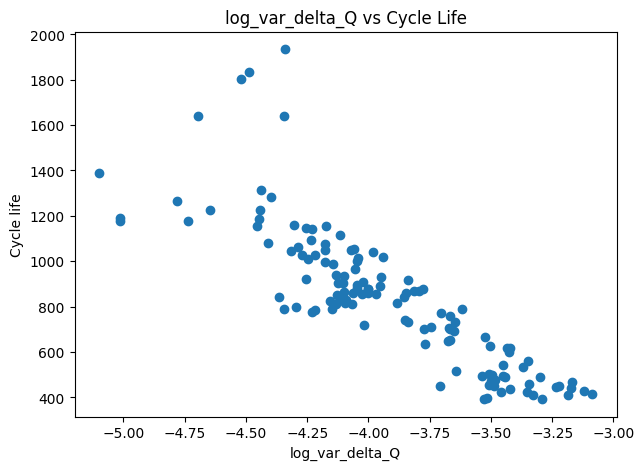

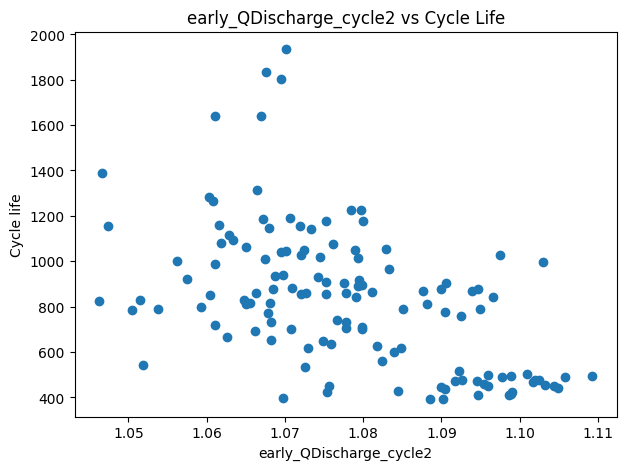

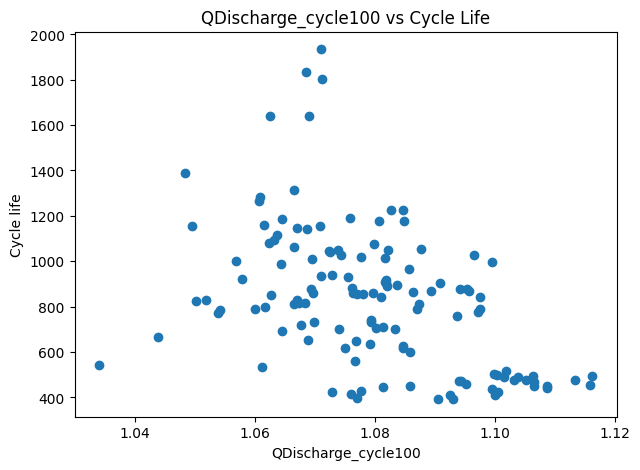

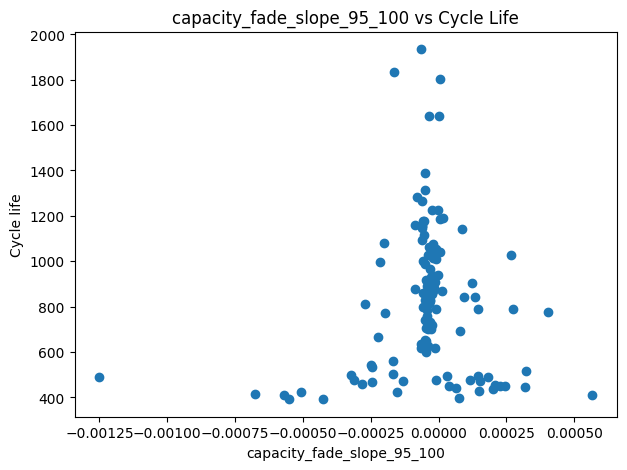

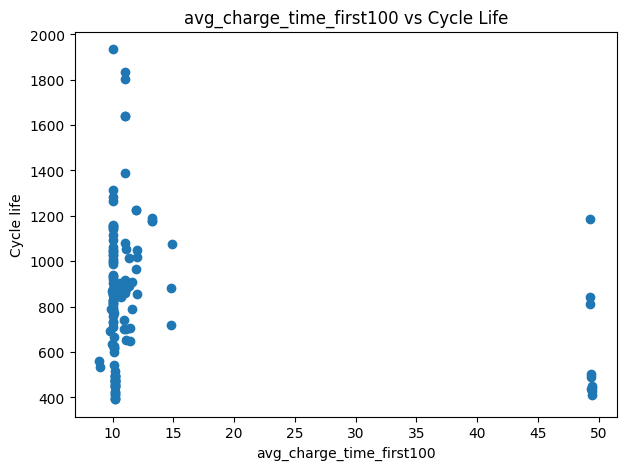

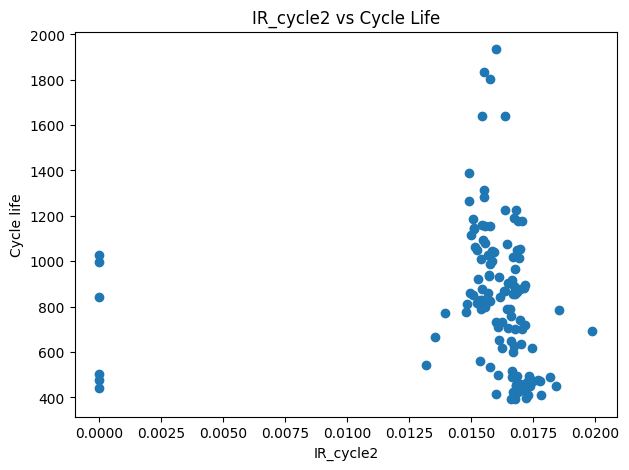

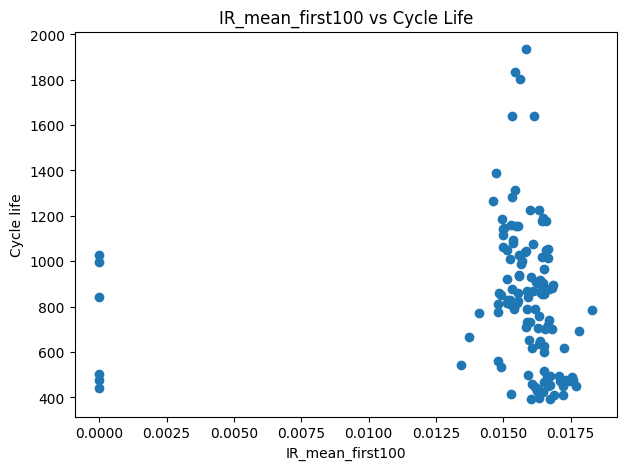

In [36]:
for feature in feature_columns:
    plt.figure(figsize=(7, 5))
    
    plt.scatter(multi_feature_df_clean[feature], multi_feature_df_clean["cycle_life"])
    
    plt.xlabel(feature)
    plt.ylabel("Cycle life")
    plt.title(f"{feature} vs Cycle Life")
    
    plt.show()

### Log Variance of ΔQ100-10(V) vs Cycle Life

This plot shows the relationship between the Week 5 baseline feature, `log_var_delta_Q`, and battery cycle life. The relationship is expected to be negative: cells with larger early-cycle discharge curve changes tend to have shorter cycle lives.

This feature remains important in the Week 6 multi-feature model because it was already useful as a one-feature baseline.

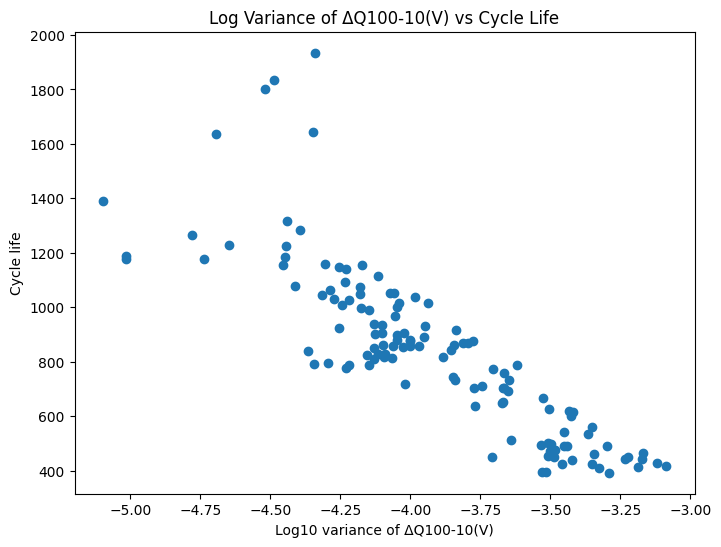

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["log_var_delta_Q"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Log10 variance of ΔQ100-10(V)")
plt.ylabel("Cycle life")
plt.title("Log Variance of ΔQ100-10(V) vs Cycle Life")

plt.show()

### Early Discharge Capacity Features

These plots compare early discharge capacity features with cycle life. Early discharge capacity alone may not show a very strong relationship with lifetime because many cells still have similar capacity during the early cycles.

This connects to the paper's motivation: early capacity fade is often small, so voltage-curve features such as `log_var_delta_Q` may be more informative.

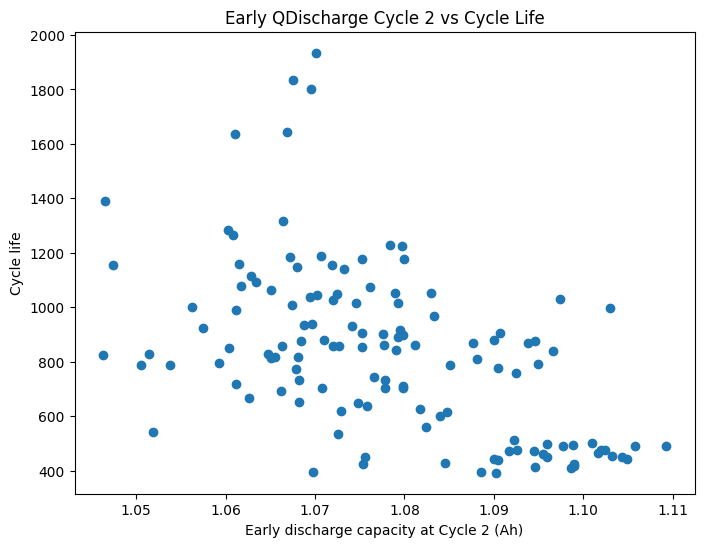

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["early_QDischarge_cycle2"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Early discharge capacity at Cycle 2 (Ah)")
plt.ylabel("Cycle life")
plt.title("Early QDischarge Cycle 2 vs Cycle Life")

plt.show()

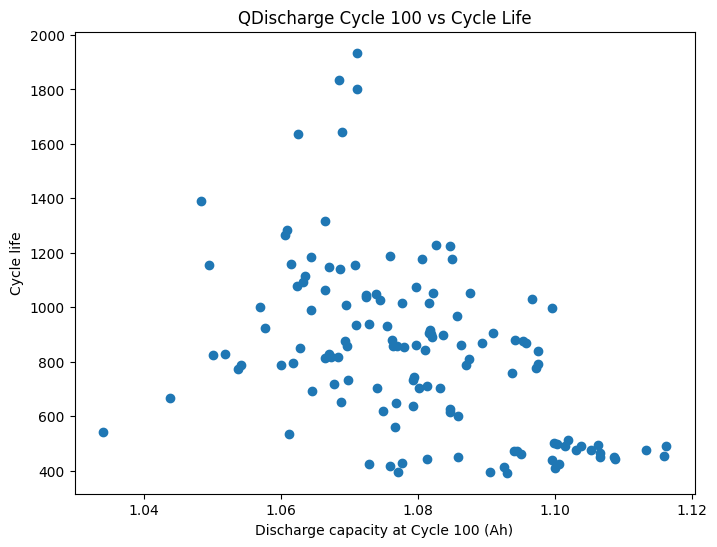

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["QDischarge_cycle100"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Discharge capacity at Cycle 100 (Ah)")
plt.ylabel("Cycle life")
plt.title("QDischarge Cycle 100 vs Cycle Life")

plt.show()

### Capacity Fade Slope vs Cycle Life

This plot shows the relationship between the early capacity fade slope and cycle life. The slope is calculated from Cycle 95 to Cycle 100 and represents how quickly discharge capacity changes during that early window.

A more negative slope may indicate faster early degradation, which could be related to shorter cycle life. This feature may help the multi-feature model capture early capacity fade behavior.

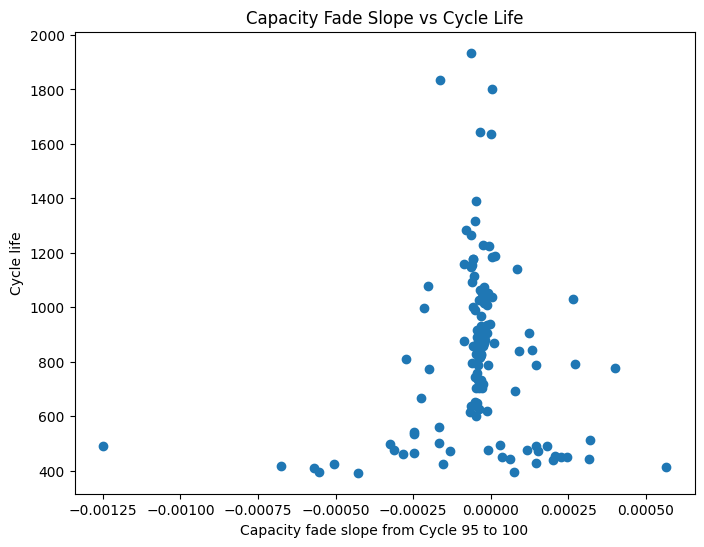

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["capacity_fade_slope_95_100"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Capacity fade slope from Cycle 95 to 100")
plt.ylabel("Cycle life")
plt.title("Capacity Fade Slope vs Cycle Life")

plt.show()

### Average Charge Time vs Cycle Life

This plot compares the average charge time during the first 100 cycles with battery cycle life. Charge time may contain information about the charging policy or cell behavior during early cycles.

This feature may be useful in the multi-feature model because different charging behavior can be related to different degradation patterns.

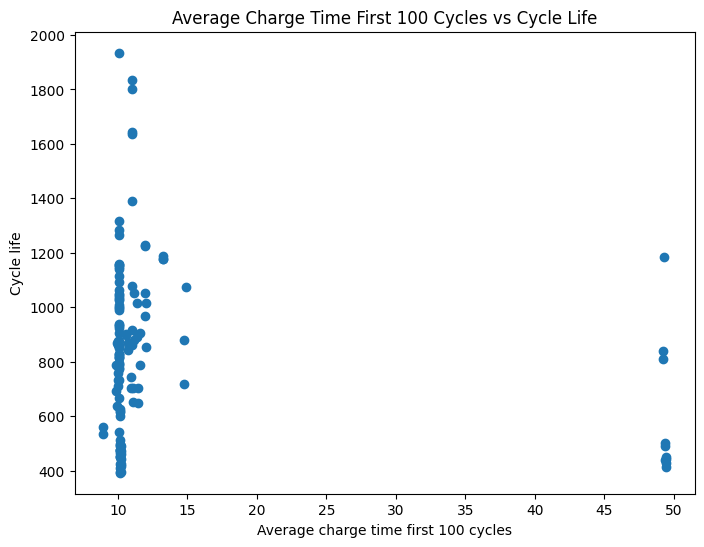

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["avg_charge_time_first100"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Average charge time first 100 cycles")
plt.ylabel("Cycle life")
plt.title("Average Charge Time First 100 Cycles vs Cycle Life")

plt.show()

### Internal Resistance Features

These plots compare internal resistance features with cycle life. Internal resistance is related to battery aging and cell health, so it may provide useful information for lifetime prediction.

The model may use these features together with discharge capacity and voltage-curve features to make better predictions than the one-feature baseline.

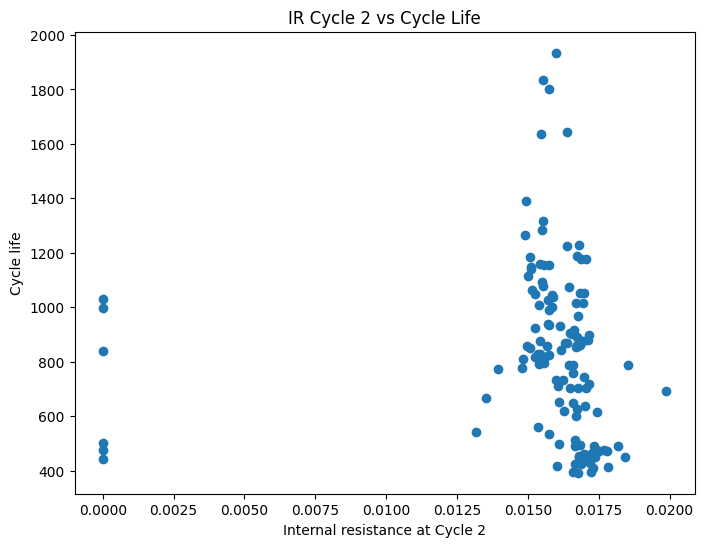

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["IR_cycle2"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Internal resistance at Cycle 2")
plt.ylabel("Cycle life")
plt.title("IR Cycle 2 vs Cycle Life")

plt.show()

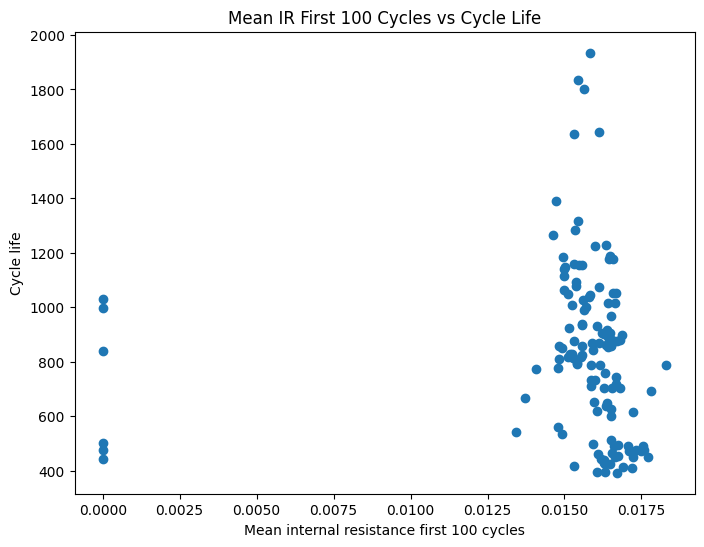

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_feature_df_clean["IR_mean_first100"],
    multi_feature_df_clean["cycle_life"]
)

plt.xlabel("Mean internal resistance first 100 cycles")
plt.ylabel("Cycle life")
plt.title("Mean IR First 100 Cycles vs Cycle Life")

plt.show()

### Feature Correlation with Cycle Life

This table shows the correlation between each input feature and `cycle_life`. A positive value means the feature increases as cycle life increases, while a negative value means the feature tends to be larger for shorter-life cells.

This table helps identify which features may be useful for the Week 6 multi-feature model.

In [44]:
correlation_table = multi_feature_df_clean[feature_columns + ["cycle_life"]].corr()["cycle_life"].drop("cycle_life")

correlation_table = correlation_table.sort_values()

correlation_table

log_var_delta_Q              -0.850609
early_QDischarge_cycle2      -0.524861
QDischarge_cycle100          -0.471396
avg_charge_time_first100     -0.194043
IR_cycle2                    -0.019184
IR_mean_first100              0.000459
capacity_fade_slope_95_100    0.088077
Name: cycle_life, dtype: float64

In [45]:
correlation_df = correlation_table.reset_index()
correlation_df.columns = ["feature", "correlation_with_cycle_life"]

correlation_df

,feature,correlation_with_cycle_life
0,log_var_delta_Q,-0.850609
1,early_QDischarge_cycle2,-0.524861
2,QDischarge_cycle100,-0.471396
3,avg_charge_time_first100,-0.194043
4,IR_cycle2,-0.019184
5,IR_mean_first100,0.000459
6,capacity_fade_slope_95_100,0.088077


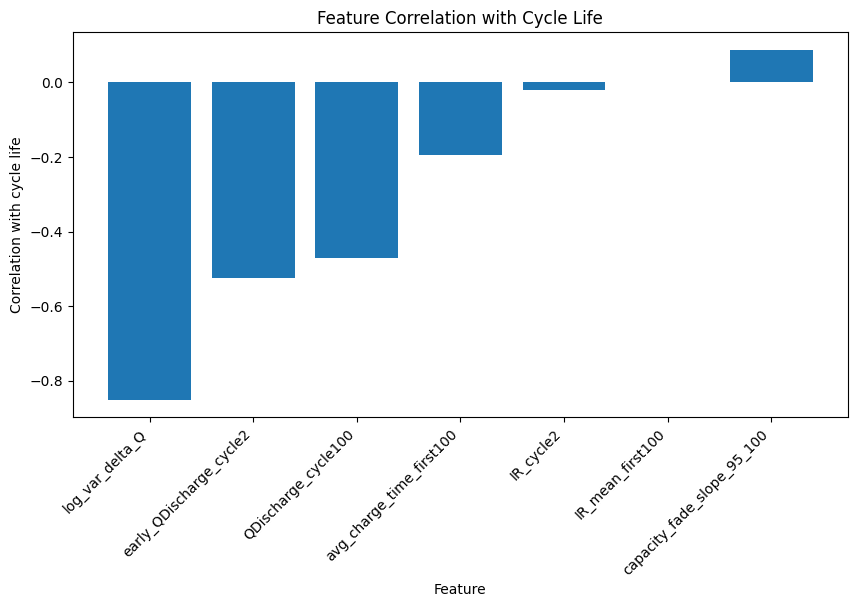

In [46]:
plt.figure(figsize=(10, 5))

plt.bar(correlation_df["feature"], correlation_df["correlation_with_cycle_life"])

plt.xlabel("Feature")
plt.ylabel("Correlation with cycle life")
plt.title("Feature Correlation with Cycle Life")
plt.xticks(rotation=45, ha="right")

plt.show()

### Feature Selection Decision

For now, I will keep all selected features for the multi-feature model. These features describe different aspects of early battery behavior, including voltage-curve change, discharge capacity, capacity fade slope, charge time, and internal resistance.

In the next step, I will train an Elastic Net model. Since Elastic Net includes regularization, it can help reduce the influence of less useful features and show which features matter more.

In [47]:
final_multi_feature_df = multi_feature_df_clean[
    ["batch_file", "cell_index", "cycle_life"] + feature_columns
].copy()

final_multi_feature_df.head()

,batch_file,cell_index,cycle_life,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,-5.014861,1.070689,1.075913,0.000015,13.250388,0.016742,0.016477
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,-5.013960,1.075301,1.080630,-0.000057,13.240949,0.017039,0.016583
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,-4.737000,1.079922,1.084940,-0.000056,13.245097,0.016868,0.016434
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,-4.442613,1.079723,1.084750,-0.000004,11.932744,0.016370,0.015985
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,-4.647744,1.078417,1.082646,-0.000026,11.932781,0.016787,0.016336


In [48]:
final_multi_feature_df.shape

(129, 10)

In [51]:
final_multi_feature_df.to_csv("week6_clean_multi_feature_data.csv", index=False)
correlation_df.to_csv("week6_feature_correlations.csv", index=False)

In [53]:
import os

os.listdir("/kaggle/working")

['.virtual_documents',
 'week6_clean_multi_feature_data.csv',
 'week6_skipped_multi_feature_cells.csv',
 'week6_multi_feature_data.csv',
 'week6_feature_correlations.csv']

### Day 2 Observation

Today, I inspected and cleaned the multi-feature dataset. I checked the data structure, missing values, feature statistics, and the relationship between each feature and cycle life.

The features describe different types of early battery behavior, including discharge curve change, early capacity, capacity fade slope, charge time, and internal resistance. Some features appear more strongly related to cycle life than others, but I will keep all selected features for now because the Elastic Net model can use regularization to reduce the effect of less useful features.

This cleaned dataset is now ready for training the Week 6 multi-feature model.

## Day 3: Train Elastic Net Multi-Feature Model

Today, I train a multi-feature Elastic Net regression model using the cleaned feature dataset. The goal is to use multiple early-cycle battery features to predict cycle life and prepare the model for comparison with the Week 5 one-feature baseline.

In [54]:
final_multi_feature_df = pd.read_csv("/kaggle/working/week6_clean_multi_feature_data.csv")

final_multi_feature_df.head()

,batch_file,cell_index,cycle_life,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,-5.014861,1.070689,1.075913,0.000015,13.250388,0.016742,0.016477
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,-5.013960,1.075301,1.080630,-0.000057,13.240949,0.017039,0.016583
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,-4.737000,1.079922,1.084940,-0.000056,13.245097,0.016868,0.016434
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,-4.442613,1.079723,1.084750,-0.000004,11.932744,0.016370,0.015985
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,-4.647744,1.078417,1.082646,-0.000026,11.932781,0.016787,0.016336


In [55]:
feature_columns = [
    "log_var_delta_Q",
    "early_QDischarge_cycle2",
    "QDischarge_cycle100",
    "capacity_fade_slope_95_100",
    "avg_charge_time_first100",
    "IR_cycle2",
    "IR_mean_first100"
]

In [56]:
X_multi = final_multi_feature_df[feature_columns]
y_multi = final_multi_feature_df["cycle_life"]

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (129, 7)
y_multi shape: (129,)


In [59]:
X_multi.isna().sum()

log_var_delta_Q               0
early_QDischarge_cycle2       0
QDischarge_cycle100           0
capacity_fade_slope_95_100    0
avg_charge_time_first100      0
IR_cycle2                     0
IR_mean_first100              0
dtype: int64

In [62]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

print("X_train_multi shape:", X_train_multi.shape)
print("X_test_multi shape:", X_test_multi.shape)
print("y_train_multi shape:", y_train_multi.shape)
print("y_test_multi shape:", y_test_multi.shape)

X_train_multi shape: (103, 7)
X_test_multi shape: (26, 7)
y_train_multi shape: (103,)
y_test_multi shape: (26,)


In [63]:
scaler = StandardScaler()

X_train_multi_scaled = scaler.fit_transform(X_train_multi)
X_test_multi_scaled = scaler.transform(X_test_multi)

In [64]:
elastic_net_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

elastic_net_model.fit(X_train_multi_scaled, y_train_multi)

ElasticNet(alpha=0.1, max_iter=10000, random_state=42)

### Elastic Net Multi-Feature Model

This model uses multiple early-cycle battery features to predict cycle life. Unlike the Week 5 baseline model, which used only `log_var_delta_Q`, this model includes discharge capacity, capacity fade slope, charge time, and internal resistance features.

Before training the model, I standardized the input features using `StandardScaler` because Elastic Net is sensitive to feature scale. Standardization makes the features more comparable and allows the regularization terms to work properly.

In [65]:
print("Intercept:", elastic_net_model.intercept_)

coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": elastic_net_model.coef_
})

coef_dfy_pred_multi = elastic_net_model.predict(X_test_multi_scaled)

print(y_pred_multi[:10])

Intercept: 843.5631067961167


,feature,coefficient
0,log_var_delta_Q,-261.968962
1,early_QDischarge_cycle2,27.388640
2,QDischarge_cycle100,-59.106428
3,capacity_fade_slope_95_100,3.050202
4,avg_charge_time_first100,-9.374640
5,IR_cycle2,-6.725978
6,IR_mean_first100,9.368361


In [66]:
y_pred_multi = elastic_net_model.predict(X_test_multi_scaled)

print(y_pred_multi[:10])

[1067.11444083  914.15986481  662.04041426  739.6280957   968.51711743
  501.46702386  565.67359451  957.97887241 1017.31850802  758.27599078]


In [68]:
multi_results_df = pd.DataFrame({
    "actual_cycle_life": y_test_multi.values,
    "predicted_cycle_life": y_pred_multi
})

multi_results_df["error_cycles"] = (
    multi_results_df["predicted_cycle_life"] - multi_results_df["actual_cycle_life"]
)

multi_results_df["absolute_error_cycles"] = abs(multi_results_df["error_cycles"])

multi_results_df["percentage_error"] = (
    multi_results_df["absolute_error_cycles"] / multi_results_df["actual_cycle_life"]
) * 100

multi_results_df.head()

,actual_cycle_life,predicted_cycle_life,error_cycles,absolute_error_cycles,percentage_error
0,791.0,1067.114441,276.114441,276.114441,34.907009
1,966.0,914.159865,-51.840135,51.840135,5.366474
2,788.0,662.040414,-125.959586,125.959586,15.984719
3,876.0,739.628096,-136.371904,136.371904,15.567569
4,935.0,968.517117,33.517117,33.517117,3.584718


### Elastic Net Actual vs Predicted Cycle Life

This plot compares the actual cycle life values with the predicted cycle life values from the multi-feature Elastic Net model.

The diagonal line represents perfect prediction. Points closer to the line indicate better predictions, while points farther away show larger errors.

This plot helps evaluate whether adding multiple battery features improves the prediction compared with the Week 5 one-feature baseline.

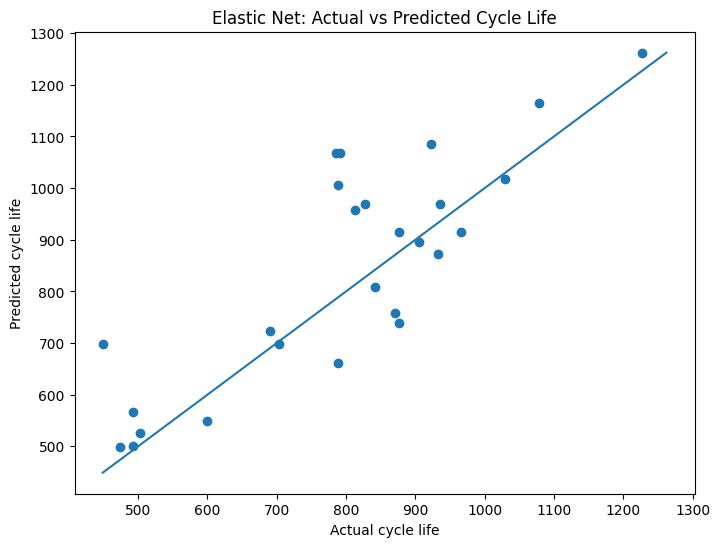

In [69]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multi_results_df["actual_cycle_life"],
    multi_results_df["predicted_cycle_life"]
)

min_life = min(
    multi_results_df["actual_cycle_life"].min(),
    multi_results_df["predicted_cycle_life"].min()
)

max_life = max(
    multi_results_df["actual_cycle_life"].max(),
    multi_results_df["predicted_cycle_life"].max()
)

plt.plot([min_life, max_life], [min_life, max_life])

plt.xlabel("Actual cycle life")
plt.ylabel("Predicted cycle life")
plt.title("Elastic Net: Actual vs Predicted Cycle Life")

plt.show()

In [70]:
mae_multi = mean_absolute_error(
    multi_results_df["actual_cycle_life"],
    multi_results_df["predicted_cycle_life"]
)

mse_multi = mean_squared_error(
    multi_results_df["actual_cycle_life"],
    multi_results_df["predicted_cycle_life"]
)

rmse_multi = np.sqrt(mse_multi)

mean_percentage_error_multi = multi_results_df["percentage_error"].mean()

print("MAE:", mae_multi)
print("RMSE:", rmse_multi)
print("Mean percentage error:", mean_percentage_error_multi)

MAE: 93.45921876823758
RMSE: 125.46148281674537
Mean percentage error: 12.634620854686204


In [71]:
multi_error_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "Mean percentage error"],
    "Value": [mae_multi, rmse_multi, mean_percentage_error_multi],
    "Unit": ["cycles", "cycles", "%"]
})

multi_error_table["Value"] = multi_error_table["Value"].round(2)

multi_error_table

,Metric,Value,Unit
0,MAE,93.46,cycles
1,RMSE,125.46,cycles
2,Mean percentage error,12.63,%


## Day 4: Compare Multi-Feature Model with Week 5 Baseline

Today, I evaluate the Elastic Net multi-feature model and compare it with the Week 5 one-feature linear regression baseline. The goal is to see whether adding more battery features improves prediction performance.

In [72]:
print("y_test_multi shape:", y_test_multi.shape)
print("y_pred_multi shape:", y_pred_multi.shape)

y_test_multi shape: (26,)
y_pred_multi shape: (26,)


In [73]:
multi_results_df = pd.DataFrame({
    "actual_cycle_life": y_test_multi.values,
    "predicted_cycle_life": y_pred_multi
})

multi_results_df["error_cycles"] = (
    multi_results_df["predicted_cycle_life"] - multi_results_df["actual_cycle_life"]
)

multi_results_df["absolute_error_cycles"] = abs(multi_results_df["error_cycles"])

multi_results_df["percentage_error"] = (
    multi_results_df["absolute_error_cycles"] / multi_results_df["actual_cycle_life"]
) * 100

multi_results_df.head()

,actual_cycle_life,predicted_cycle_life,error_cycles,absolute_error_cycles,percentage_error
0,791.0,1067.114441,276.114441,276.114441,34.907009
1,966.0,914.159865,-51.840135,51.840135,5.366474
2,788.0,662.040414,-125.959586,125.959586,15.984719
3,876.0,739.628096,-136.371904,136.371904,15.567569
4,935.0,968.517117,33.517117,33.517117,3.584718


In [74]:
mae_multi = mean_absolute_error(
    multi_results_df["actual_cycle_life"],
    multi_results_df["predicted_cycle_life"]
)

mse_multi = mean_squared_error(
    multi_results_df["actual_cycle_life"],
    multi_results_df["predicted_cycle_life"]
)

rmse_multi = np.sqrt(mse_multi)

mean_percentage_error_multi = multi_results_df["percentage_error"].mean()

print("Elastic Net MAE:", mae_multi)
print("Elastic Net RMSE:", rmse_multi)
print("Elastic Net Mean Percentage Error:", mean_percentage_error_multi)

Elastic Net MAE: 93.45921876823758
Elastic Net RMSE: 125.46148281674537
Elastic Net Mean Percentage Error: 12.634620854686204


### Elastic Net Model Error

This table summarizes the prediction error of the multi-feature Elastic Net model. MAE and RMSE report the error in cycle units, while mean percentage error reports the average error relative to the true cycle life.

This model uses multiple early-cycle battery features, so the next step is to compare it with the Week 5 one-feature baseline.

In [75]:
multi_error_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "Mean percentage error"],
    "Value": [mae_multi, rmse_multi, mean_percentage_error_multi],
    "Unit": ["cycles", "cycles", "%"]
})

multi_error_table["Value"] = multi_error_table["Value"].round(2)

multi_error_table

,Metric,Value,Unit
0,MAE,93.46,cycles
1,RMSE,125.46,cycles
2,Mean percentage error,12.63,%


In [80]:
X_train_baseline = X_train_multi[["log_var_delta_Q"]]
X_test_baseline = X_test_multi[["log_var_delta_Q"]]

baseline_model = LinearRegression()
baseline_model.fit(X_train_baseline, y_train_multi)

y_pred_baseline = baseline_model.predict(X_test_baseline)

In [81]:
baseline_results_df = pd.DataFrame({
    "actual_cycle_life": y_test_multi.values,
    "predicted_cycle_life": y_pred_baseline
})

baseline_results_df["error_cycles"] = (
    baseline_results_df["predicted_cycle_life"] - baseline_results_df["actual_cycle_life"]
)

baseline_results_df["absolute_error_cycles"] = abs(baseline_results_df["error_cycles"])

baseline_results_df["percentage_error"] = (
    baseline_results_df["absolute_error_cycles"] / baseline_results_df["actual_cycle_life"]
) * 100

baseline_results_df.head()

,actual_cycle_life,predicted_cycle_life,error_cycles,absolute_error_cycles,percentage_error
0,791.0,1120.043310,329.043310,329.043310,41.598396
1,966.0,933.926769,-32.073231,32.073231,3.320210
2,788.0,653.795410,-134.204590,134.204590,17.031039
3,876.0,755.360670,-120.639330,120.639330,13.771613
4,935.0,962.893776,27.893776,27.893776,2.983292


In [82]:
mae_baseline = mean_absolute_error(
    baseline_results_df["actual_cycle_life"],
    baseline_results_df["predicted_cycle_life"]
)

mse_baseline = mean_squared_error(
    baseline_results_df["actual_cycle_life"],
    baseline_results_df["predicted_cycle_life"]
)

rmse_baseline = np.sqrt(mse_baseline)

mean_percentage_error_baseline = baseline_results_df["percentage_error"].mean()

print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline Mean Percentage Error:", mean_percentage_error_baseline)

Baseline MAE: 102.00291012404607
Baseline RMSE: 129.79696765799338
Baseline Mean Percentage Error: 14.314052456766602


### Model Comparison

This table compares the Week 5 one-feature linear regression baseline with the Week 6 multi-feature Elastic Net model.

The one-feature model uses only `log_var_delta_Q`, while the Elastic Net model uses multiple early-cycle battery features, including discharge capacity, capacity fade slope, charge time, and internal resistance.

Using the same train/test split makes the comparison fair because both models are evaluated on the same test cells.

In [83]:
comparison_table = pd.DataFrame({
    "Model": [
        "One-feature Linear Regression",
        "Multi-feature Elastic Net"
    ],
    "Features": [
        "log_var_delta_Q",
        "Multiple battery features"
    ],
    "MAE": [
        mae_baseline,
        mae_multi
    ],
    "RMSE": [
        rmse_baseline,
        rmse_multi
    ],
    "Mean percentage error": [
        mean_percentage_error_baseline,
        mean_percentage_error_multi
    ]
})

comparison_table[["MAE", "RMSE", "Mean percentage error"]] = comparison_table[
    ["MAE", "RMSE", "Mean percentage error"]
].round(2)

comparison_table

,Model,Features,MAE,RMSE,Mean percentage error
0,One-feature Linear Regression,log_var_delta_Q,102.00,129.80,14.31
1,Multi-feature Elastic Net,Multiple battery features,93.46,125.46,12.63


In [84]:
improvement_percent = (
    (mean_percentage_error_baseline - mean_percentage_error_multi)
    / mean_percentage_error_baseline
) * 100

print("Improvement in mean percentage error:", improvement_percent)

Improvement in mean percentage error: 11.73274729258442


In [85]:
if improvement_percent > 0:
    print("The multi-feature model improved over the one-feature baseline.")
else:
    print("The multi-feature model did not improve over the one-feature baseline.") v

The multi-feature model improved over the one-feature baseline.


### Model Comparison Plot

This bar chart compares the mean percentage error of the one-feature baseline model and the multi-feature Elastic Net model.

A lower percentage error means better prediction performance. This plot helps show whether adding more battery features improved the model compared with the simpler Week 5 baseline.

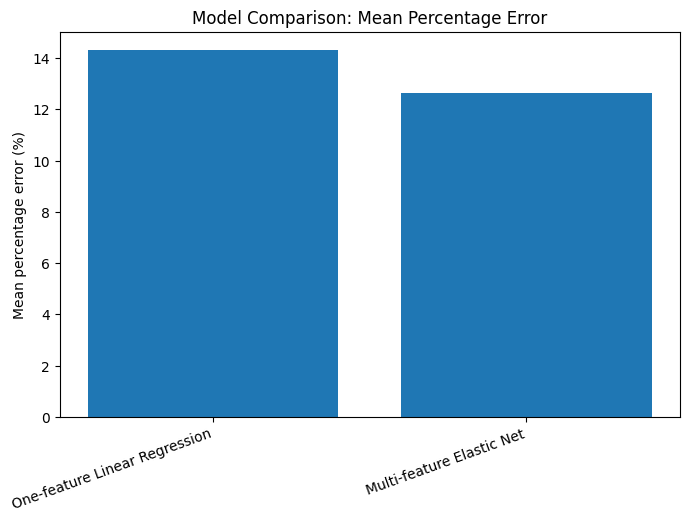

In [86]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Mean percentage error"]
)

plt.ylabel("Mean percentage error (%)")
plt.title("Model Comparison: Mean Percentage Error")
plt.xticks(rotation=20, ha="right")

plt.show()

In [87]:
coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": elastic_net_model.coef_
})

coef_df["absolute_coefficient"] = abs(coef_df["coefficient"])

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

coef_df

,feature,coefficient,absolute_coefficient
0,log_var_delta_Q,-261.968962,261.968962
2,QDischarge_cycle100,-59.106428,59.106428
1,early_QDischarge_cycle2,27.388640,27.388640
4,avg_charge_time_first100,-9.374640,9.374640
6,IR_mean_first100,9.368361,9.368361
5,IR_cycle2,-6.725978,6.725978
3,capacity_fade_slope_95_100,3.050202,3.050202


### Elastic Net Feature Coefficients

This plot shows the coefficients learned by the Elastic Net model after feature standardization. Since the features were standardized before training, the coefficients are easier to compare.

A positive coefficient means the feature is associated with higher predicted cycle life, while a negative coefficient means the feature is associated with lower predicted cycle life. Features with coefficients close to zero have less influence in this model.

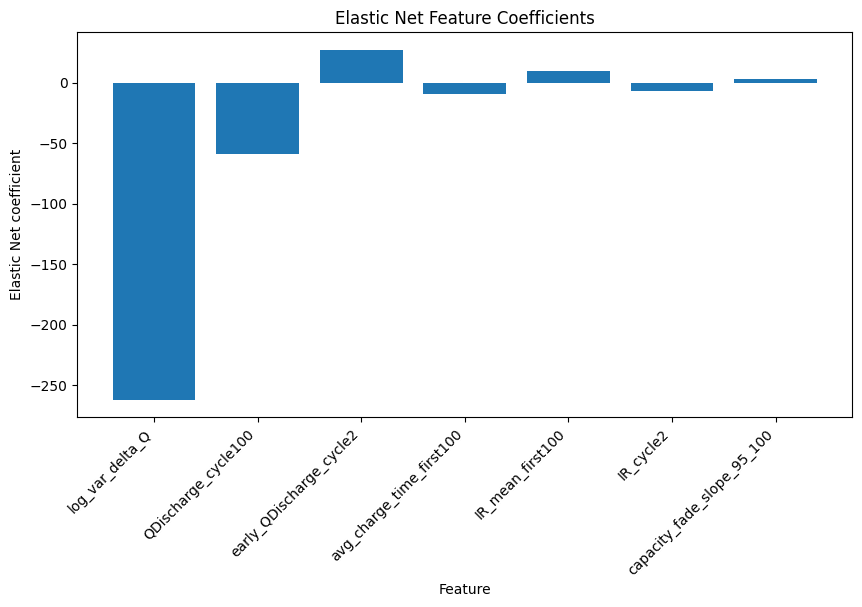

In [88]:
plt.figure(figsize=(10, 5))

plt.bar(coef_df["feature"], coef_df["coefficient"])

plt.xlabel("Feature")
plt.ylabel("Elastic Net coefficient")
plt.title("Elastic Net Feature Coefficients")
plt.xticks(rotation=45, ha="right")

plt.show()

### Day 4 Observation

The comparison table shows that the multi-feature Elastic Net model performed better than the one-feature linear regression baseline.

The one-feature baseline model had a MAE of 102.00 cycles, RMSE of 129.80 cycles, and mean percentage error of 14.31%. The multi-feature Elastic Net model improved these results, with a MAE of 93.46 cycles, RMSE of 125.46 cycles, and mean percentage error of 12.63%.

This means that adding more battery features helped reduce the prediction error. The mean percentage error decreased from 14.31% to 12.63%, which shows that the multi-feature model gives more accurate predictions on the test set.

However, the improvement is not extremely large. This suggests that the Week 5 feature, `log_var_delta_Q`, already captures a strong amount of useful lifetime information. The additional features still help, but the log variance feature remains an important baseline feature for predicting battery cycle life.

## Day 5: Notebook Cleanup and Final Summary

Today, I clean and organize the Week 6 multi-feature model notebook. The goal is to clearly present the full workflow, including feature preparation, data cleaning, Elastic Net model training, model evaluation, comparison with the Week 5 baseline, and final observations.

In [89]:
final_multi_feature_df.head()

,batch_file,cell_index,cycle_life,log_var_delta_Q,early_QDischarge_cycle2,QDischarge_cycle100,capacity_fade_slope_95_100,avg_charge_time_first100,IR_cycle2,IR_mean_first100
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,-5.014861,1.070689,1.075913,0.000015,13.250388,0.016742,0.016477
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,-5.013960,1.075301,1.080630,-0.000057,13.240949,0.017039,0.016583
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,-4.737000,1.079922,1.084940,-0.000056,13.245097,0.016868,0.016434
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,-4.442613,1.079723,1.084750,-0.000004,11.932744,0.016370,0.015985
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,-4.647744,1.078417,1.082646,-0.000026,11.932781,0.016787,0.016336


In [90]:
multi_error_table

,Metric,Value,Unit
0,MAE,93.46,cycles
1,RMSE,125.46,cycles
2,Mean percentage error,12.63,%


### Model Comparison

This table compares the Week 5 one-feature linear regression baseline with the Week 6 multi-feature Elastic Net model.

The one-feature baseline used only `log_var_delta_Q`, while the Elastic Net model used multiple battery features, including early discharge capacity, discharge capacity at Cycle 100, capacity fade slope, average charge time, and internal resistance.

The multi-feature Elastic Net model achieved lower error than the one-feature baseline. The mean percentage error decreased from 14.31% to 12.63%, showing that adding more features improved prediction performance.

In [91]:
comparison_table

,Model,Features,MAE,RMSE,Mean percentage error
0,One-feature Linear Regression,log_var_delta_Q,102.00,129.80,14.31
1,Multi-feature Elastic Net,Multiple battery features,93.46,125.46,12.63


In [92]:
coef_df

,feature,coefficient,absolute_coefficient
0,log_var_delta_Q,-261.968962,261.968962
2,QDischarge_cycle100,-59.106428,59.106428
1,early_QDischarge_cycle2,27.388640,27.388640
4,avg_charge_time_first100,-9.374640,9.374640
6,IR_mean_first100,9.368361,9.368361
5,IR_cycle2,-6.725978,6.725978
3,capacity_fade_slope_95_100,3.050202,3.050202


### Improvement from Baseline

The multi-feature Elastic Net model reduced the mean percentage error from 14.31% to 12.63%. This is about an 11.7% relative improvement compared with the one-feature baseline.

This suggests that the additional features provide useful information, although the improvement is moderate. The Week 5 feature `log_var_delta_Q` remains very important because the one-feature model was already reasonably strong.

In [93]:
improvement_percent = (
    (mean_percentage_error_baseline - mean_percentage_error_multi)
    / mean_percentage_error_baseline
) * 100

print("Improvement in mean percentage error:", improvement_percent)

Improvement in mean percentage error: 11.73274729258442


In [94]:
coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": elastic_net_model.coef_
})

coef_df["absolute_coefficient"] = abs(coef_df["coefficient"])

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

coef_df

,feature,coefficient,absolute_coefficient
0,log_var_delta_Q,-261.968962,261.968962
2,QDischarge_cycle100,-59.106428,59.106428
1,early_QDischarge_cycle2,27.388640,27.388640
4,avg_charge_time_first100,-9.374640,9.374640
6,IR_mean_first100,9.368361,9.368361
5,IR_cycle2,-6.725978,6.725978
3,capacity_fade_slope_95_100,3.050202,3.050202


### Elastic Net Feature Coefficients

This plot shows the coefficients learned by the Elastic Net model after feature standardization. Since the input features were standardized before training, the coefficients are easier to compare.

A positive coefficient means the feature is associated with higher predicted cycle life, while a negative coefficient means the feature is associated with lower predicted cycle life. Features with coefficients closer to zero have less influence in this model.

### Feature Coefficient Observation

This plot shows the coefficients learned by the Elastic Net model for each feature.

`log_var_delta_Q` has the largest absolute coefficient, so it seems to be the most important feature in this model. `QDischarge_cycle100` also has a relatively large coefficient, which means it also plays an important role.

The other features have smaller coefficients, so they still help the model, but their influence is weaker. This suggests that the Week 5 feature is still very strong, and the extra Week 6 features improve the model by adding more useful information.

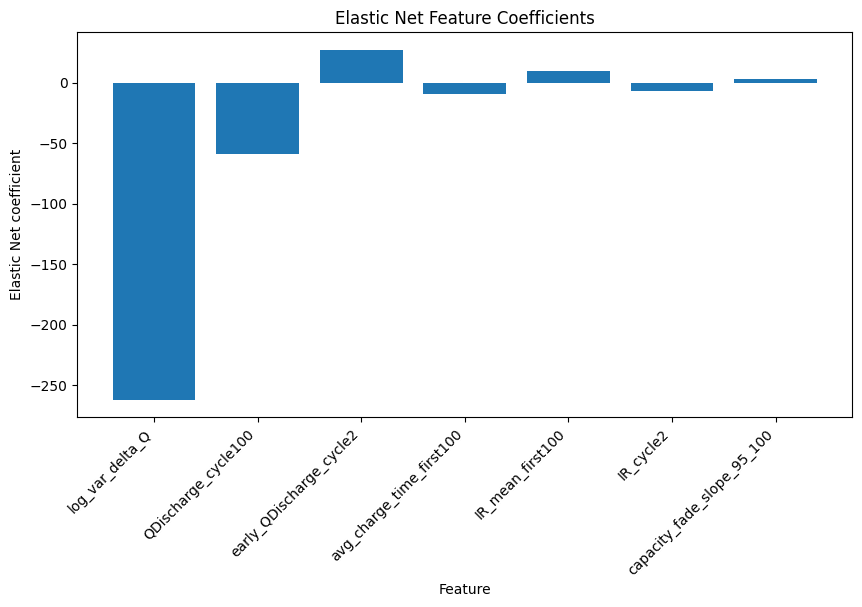

In [95]:
plt.figure(figsize=(10, 5))

plt.bar(coef_df["feature"], coef_df["coefficient"])

plt.xlabel("Feature")
plt.ylabel("Elastic Net coefficient")
plt.title("Elastic Net Feature Coefficients")
plt.xticks(rotation=45, ha="right")

plt.show()

## Final Observations for this week

This week, I built a multi-feature Elastic Net regression model to predict battery cycle life. I added several features beyond the Week 5 baseline feature, including early discharge capacity, discharge capacity at Cycle 100, capacity fade slope, average charge time, and internal resistance.

I cleaned and inspected the multi-feature dataset, checked feature relationships with cycle life, trained an Elastic Net model, and compared its performance with the Week 5 one-feature linear regression baseline.

The one-feature baseline model had a MAE of 102.00 cycles, RMSE of 129.80 cycles, and mean percentage error of 14.31%. The multi-feature Elastic Net model improved the results with a MAE of 93.46 cycles, RMSE of 125.46 cycles, and mean percentage error of 12.63%.

This shows that adding multiple battery features helped reduce prediction error. However, the improvement was moderate, which suggests that `log_var_delta_Q` is already a strong feature. The multi-feature model provides a better result and gives a useful comparison against the simpler Week 5 baseline.

In [96]:
final_multi_feature_df.to_csv("week6_clean_multi_feature_data.csv", index=False)
comparison_table.to_csv("week6_model_comparison_table.csv", index=False)
coef_df.to_csv("week6_elastic_net_coefficients.csv", index=False)

In [97]:
import os

os.listdir("/kaggle/working")

['.virtual_documents',
 'week6_clean_multi_feature_data.csv',
 'week6_skipped_multi_feature_cells.csv',
 'week6_multi_feature_data.csv',
 'week6_model_comparison_table.csv',
 'week6_elastic_net_coefficients.csv',
 'week6_feature_correlations.csv']